Name: Rumpa Biswas

# Project Title: Hate Speech Detection: Analyzing and Detecting Toxic Language for Safer Online Communities

## Project Description:

This project aims to develop a machine learning model that automatically classifies social media text into two categories: hate (including both hate speech and offensive language) and neutral. The dataset used includes tweets labeled as hate speech, offensive, or neutral. To simplify and sharpen the model’s focus on identifying potentially harmful content, we combine the hate speech and offensive categories into a single “hate” class. This is because both types of language can contribute to a toxic online environment, even if their intent or severity differs

I chose this topic because of the growing importance of creating safer digital spaces, especially on social platforms where unmoderated toxic content can lead to real-world harm.


## Background:

The dataset used in this project is sourced from Kaggle's Hate Speech and Offensive Language Dataset. It contains thousands of tweets categorized into three classes: hate speech, offensive language, and neutral content. The dataset has been widely used in NLP research and provides a solid foundation for building content moderation tools.

Kaggle Dataset Link: https://www.kaggle.com/datasets/yashdogra/toxic-tweets

Other resources and inspirations:

    -Natural Language Toolkit (NLTK) and Scikit-learn for preprocessing and modeling.

    -Research papers on hate speech detection and toxic language analysis.


In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn import metrics
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.classify import NaiveBayesClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

## Load and Explore Dataset:

First, we load the dataset from a CSV file and take an initial look at its structure. We display the first few rows to get a sense of the data 
format and content. Additionally, we check the total number of rows and columns to understand the dataset size.

In [118]:
data = pd.read_csv('labeled_data.csv')
display(data.head())
print('Rows, Columns:', data.shape)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Rows, Columns: (24783, 7)


## Checking for Missing Values:

Before proceeding with data preprocessing and modeling, it is essential to ensure that the dataset does not contain missing values. Missing data can lead to unexpected errors or inaccurate model performance.
The code below checks each column in the dataset and returns True if any missing (NaN) values are found in that column, and False otherwise.

In [119]:
data.isna().any()

Unnamed: 0            False
count                 False
hate_speech           False
offensive_language    False
neither               False
class                 False
tweet                 False
dtype: bool

## Converting 'Offensive Language' to 'Hate Speech'

In this project, we simplify the classification task by merging 'offensive language' into 'hate speech', resulting in two categories:

    -Normal/Clean Language

    -Problematic Language (combining offensive and hate speech)

This conversion is done for several key reasons in a beginner ML project:

    -Simplification: Reduces the problem to a clearer binary outcome.

    -Class Imbalance: Helps balance the 'problematic' class, improving model training.

    -Initial Filtering: Aims to identify any content needing review, regardless of precise severity.

    -Shared Characteristics: Acknowledges the difficulty for basic models to differentiate between offensive and hate speech due to similar vocabulary and tone.

    -Core Skill Focus: Allows concentration on fundamental NLP and ML concepts without immediate deep dive into multi-class nuances.

While real-world applications demand more granular distinctions, this simplification builds a strong foundational understanding.

In [120]:
data['class'] = data['class'].replace({1 : 0})
display(data.head())

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,0,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,0,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,0,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,0,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Exploratory Data Analysis (EDA): Class Distribution

As part of the EDA process, we examine the distribution of tweets across the different classes. Understanding the balance of the dataset is crucial because an imbalanced dataset can affect how well the model learns to distinguish between categories. Here, we count the number of tweets in each class and visualize the results using a bar chart to get a clear picture of the data composition.

class
0    20620
2     4163
Name: count, dtype: int64


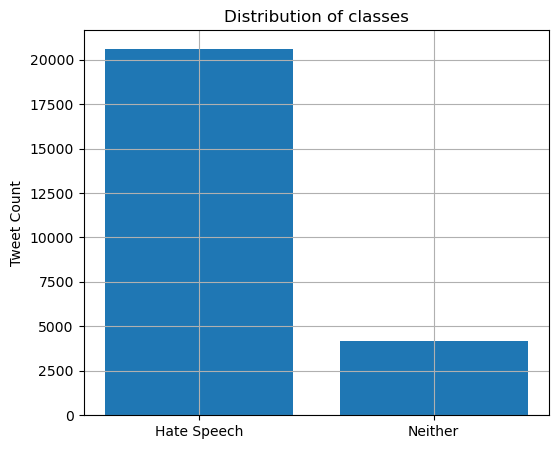

In [121]:
count = data['class'].value_counts().sort_index()
print(count)
class_names = ['Hate Speech', 'Neither']
fig = plt.figure(figsize = (6,5))
plt.bar(class_names, count.values)
plt.ylabel('Tweet Count')
plt.title('Distribution of classes')
plt.grid()
plt.show()

## Dropping Unnecessary Columns:

To simplify the dataset and focus on the essential features, we remove columns that are not needed for analysis or modeling. This includes index columns and separate label columns that are redundant after combining the classes. Cleaning up the dataset helps streamline further processing.

In [122]:
data = data.drop(columns = ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'])
display(data.head())

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,0,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,0,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,0,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,0,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Ensuring Consistent Data Type for Text Column:

To avoid errors during text processing, we convert all entries in the 'tweet' column to string data type. This ensures that subsequent cleaning and analysis steps handle the text data correctly, even if some entries were originally stored as other types.

In [123]:
data['tweet'] = data['tweet'].astype(str)

## Separating Data by Class Labels:

To facilitate targeted analysis, we identify and separate the indexes of tweets labeled as hate speech (class 0) and neutral content (class 2). This allows us to perform class-specific operations or comparisons later in the analysis.

In [124]:
hateIndex = data[data['class'] == 0].index
neitherIndex = data[data['class'] == 2].index

## Defining Features and Labels:

We separate the dataset into features (X), which contains the tweet texts, and labels (y), which contains the corresponding class for each tweet. This is a key step before feeding data into a machine learning model. We also check the shapes of both to confirm the data dimensions.

In [125]:
X= data.tweet
y = data['class']
print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (24783,)
Shape of y:  (24783,)


## Text Preprocessing: Cleaning and Normalizing Tweets:

In this step, we clean and prepare the tweet texts for modeling by:

    -Removing URLs, retweet indicators, user mentions, and hashtags to eliminate noise.

    -Removing punctuation and numbers to keep only alphabetic characters.

    -Converting all text to lowercase for consistency.

    -Removing common English stop words that add little meaning.

    -Applying stemming to reduce words to their root form, helping to unify similar words (e.g., "running" → "run").

This preprocessing improves the quality of input data and helps the model focus on meaningful patterns.

In [126]:
'''
Remove all numbers and punctuation (keep only letters).
Convert all text to lowercase.
Remove stop words.
Apply stemming to reduce words to their root form.
'''

tokenizer = RegexpTokenizer(r'\b[A-za-z]+\b')
stemmer = PorterStemmer()
stopWords = set(stopwords.words('english'))

def processor(text):
     # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove RT (retweet indicator)
    text = re.sub(r'\bRT\b', '', text)
    # Remove user mentions (@username)
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation (before tokenization to ensure clean tokens)
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    #text = re.sub(r'\d+', '', text)
    token = tokenizer.tokenize(text)
    token = [t.lower() for t in token]
    token = [t for t in token if t not in stopWords]
    token = [stemmer.stem(t) for t in token]
    return ' '.join(token)

X_processed = X.apply(processor).to_frame(name = 'tweet')
display(X_processed.head(10))

,tweet
0,woman shouldnt complain clean hous amp man alw...
1,boy dat coldtyga dwn bad cuffin dat hoe place
2,dawg ever fuck bitch start cri confus shit
3,look like tranni
4,shit hear might true might faker bitch told ya
5,shit blow meclaim faith somebodi still fuck hoe
6,sit hate anoth bitch got much shit go
7,caus im tire big bitch come us skinni girl
8,amp might get ya bitch back amp that
9,hobbi includ fight mariam bitch


## Token Frequency Analysis for Hate Tweets:

To understand the common language patterns within hate speech and offensive tweets, we aggregate all hate-class tweets into one text. We then tokenize this combined text and calculate the frequency distribution of each word. This helps identify the top words most frequently used in hate speech, providing insights into the vocabulary and themes common in toxic content.

We display the top ten tokens along with their frequencies and visualize them in a bar plot.

Top ten tokens from hate tweet:

bitch   hoe  like  fuck pussi nigga    im  dont   ass   get 
11306  4233  2543  2249  2195  1988  1867  1610  1581  1560 



Text(0, 0.5, 'Frequency')

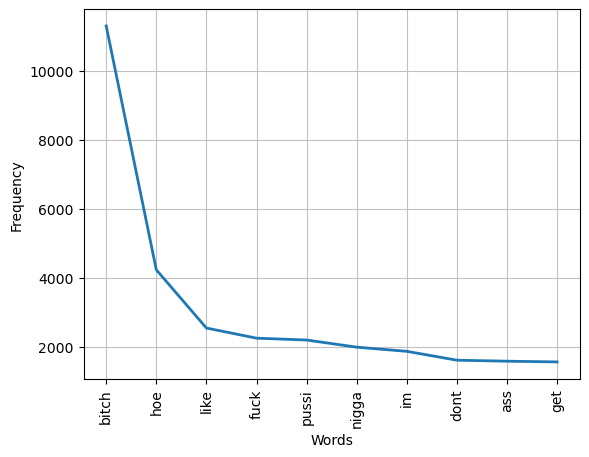

In [127]:
hateTweet = X_processed.loc[hateIndex, 'tweet']
all_hate_text = ' '.join(hateTweet.tolist())
token = word_tokenize(all_hate_text)
freq = nltk.FreqDist(token)
print('Top ten tokens from hate tweet:')
print()
freq.tabulate(10)
print()
freq.plot(10)
plt.xlabel('Words')
plt.ylabel('Frequency')

## Token Frequency Analysis for Neutral Tweets:

Similarly, we aggregate all neutral-class tweets and tokenize the combined text to analyze the most frequently used words. This reveals the common vocabulary in neutral or non-offensive content, allowing us to compare linguistic patterns between neutral and hate speech tweets.

The top ten tokens are displayed along with their frequencies and visualized in a bar plot for clear comparison.

Top ten tokens from neutral tweet:

 trash   bird   like charli     im    get yellow  yanke   dont    amp 
   690    455    312    260    220    215    214    184    174    166 



Text(0, 0.5, 'Frequency')

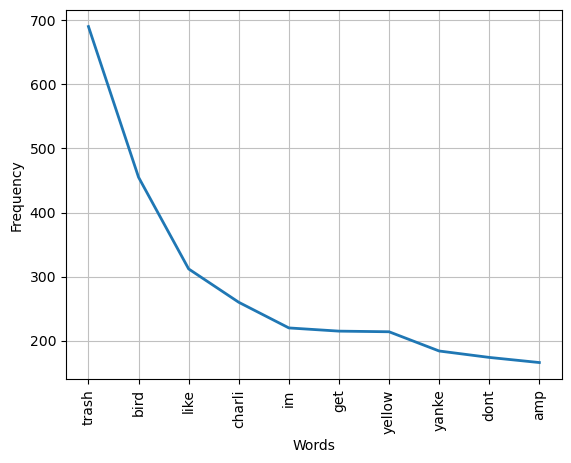

In [139]:
neitherTweet = X_processed.loc[neitherIndex, 'tweet']
all_neither_text = ' '.join(neitherTweet.tolist())
token = word_tokenize(all_neither_text)
freq = nltk.FreqDist(token)
print('Top ten tokens from neutral tweet:')
print()
freq.tabulate(10)
print()
freq.plot(10)
plt.xlabel('Words')
plt.ylabel('Frequency')

## Text Vectorization using Count Vectorizer:

To prepare the text data for machine learning models, we convert the cleaned tweets into a numerical format. The CountVectorizer transforms the text into a matrix of token counts, where each row represents a tweet and each column represents a unique word from the dataset.

This step converts our textual data into a structured numeric form that algorithms can process. The output shape indicates the number of tweets and the size of the vocabulary (unique tokens) extracted.

In [129]:
vectorizer = CountVectorizer()
vectorizer.fit(X_processed.tweet)
Xvector = vectorizer.transform(X_processed.tweet)
print('Shape of numeric X dataset', Xvector.shape)

Shape of numeric X dataset (24783, 15572)


## Model Training and Evaluation:

We split the dataset into training and testing sets, using 75% of the data for training and 25% for testing. This allows us to train the model on one portion of the data and evaluate its performance on unseen data.

A Multinomial Naive Bayes classifier is chosen due to its effectiveness with text classification problems involving word counts. After training the model, we predict the classes for the test set and calculate the accuracy score to measure overall performance.

Finally, a confusion matrix is displayed to provide detailed insights into how well the model classified each class, showing true positives, false positives, and other outcomes.

In [140]:
X_train,X_test,y_train,y_test = train_test_split(Xvector,y, test_size = 0.25, random_state = 1)
print('Shape of X_train, y_train: ', X_train.shape, y_train.shape)
print('Shape of X_test, y_test: ', X_test.shape, y_test.shape)
print()
model =  MultinomialNB()
model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy score: ', metrics.accuracy_score(y_test, y_pred))
labels = sorted(y.unique())
#print(labels)
print()
print('Confusion matrix:')
print(metrics.confusion_matrix(y_test, y_pred, labels = labels))

Shape of X_train, y_train:  (18587, 15572) (18587,)
Shape of X_test, y_test:  (6196, 15572) (6196,)

Accuracy score:  0.9226920593931569

Confusion matrix:
[[5051  137]
 [ 342  666]]


## Testing the Model with Sample Tweets:

To see how well the trained model performs on new, unseen examples, we test it on a small set of sample tweets. These samples include both offensive and neutral content with known expected labels.

We preprocess the tweets using the same text cleaning steps as before, transform them into numeric vectors, and then use the trained model to predict their classes. Finally, we compare the predicted labels against the expected ones to evaluate the model’s real-world applicability.

In [138]:
sample_tweets = pd.DataFrame({
    'tweets': [
        "You're such a bitch, get out of here.",
        "Just saw a cool bird outside.",
        "Fuck off, you're worthless.",
        "Reading a fascinating book right now."
    ]
})

# 0 = Hate Speech, 2 = Neutral
expected_label = [0, 2, 0, 2]

sample_tweets_processed = sample_tweets['tweets'].apply(processor).to_frame(name='tweets')
vector = vectorizer.transform(sample_tweets_processed['tweets'])
predicted_label = model.predict(vector)

comparison_df = pd.DataFrame({
    'Review': sample_tweets['tweets'],
    'Expected Class': expected_label,
    'Predicted Class': predicted_label
})

display(comparison_df)

,Review,Expected Class,Predicted Class
0,"You're such a bitch, get out of here.",0,0
1,Just saw a cool bird outside.,2,2
2,"Fuck off, you're worthless.",0,0
3,Reading a fascinating book right now.,2,0
